# Baseline Comparison — POW (BirdSet)

Runs all four baseline sampling strategies on the **POW** dataset with a shared
configuration to establish baseline performance and inform a reasonable `MAX_BUDGET`.

Strategies compared:
- `random` — random sampling (challenge baseline)
- `sklearn_margin_multilabel` — uncertainty-based margin sampling
- `sklearn_coreset` — diversity-based coreset selection
- `sklearn_typiclust` — typicality clustering

**AULC** (Area Under the Learning Curve) is the primary metric:

$$\text{AULC} = \frac{\int_{n_0}^{n_\text{max}} \text{mAP}(n)\, dn}{n_\text{max} - n_0}$$

In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path().absolute().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from core.active_learner import ActiveLearner

c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
core.active_learner - INFO - Pre-warming UMAP (triggering numba JIT compilation)...
core.active_learner - INFO - UMAP pre-warming completed in 8.962896823883057


In [2]:
# ---------------------------------------------------------------------------
# Shared baseline configuration — same across all datasets
# ---------------------------------------------------------------------------

# AL loop parameters
N_CYCLES            = 5
EPOCHS_PER_CYCLE    = 10
BATCH_SIZE          = 32
N_SAMPLES_PER_CYCLE = 50    # fixed per cycle (no scheduler)
N_REPEATS           = 5     # independent runs per strategy (for SD estimates)

# Optional budget cap — None means no cap (explore full budget)
MAX_BUDGET: int | None = None

# Warm-up samples before the AL loop (None = cold start)
PRETRAIN_SAMPLES: int | None = None

# Baseline strategies to compare
STRATEGIES = [
    "random",
    "sklearn_margin_multilabel",
    "sklearn_coreset",
    # "sklearn_typiclust",
]

print(f"Cycles            : {N_CYCLES}")
print(f"Samples per cycle : {N_SAMPLES_PER_CYCLE}")
print(f"Epochs per cycle  : {EPOCHS_PER_CYCLE}")
print(f"Repeats           : {N_REPEATS}")
print(f"Max budget        : {MAX_BUDGET or 'none'}")
print(f"Strategies        : {STRATEGIES}")

Cycles            : 5
Samples per cycle : 50
Epochs per cycle  : 10
Repeats           : 5
Max budget        : none
Strategies        : ['random', 'sklearn_margin_multilabel', 'sklearn_coreset']


## Step 1: Dataset paths

Set paths for the POW dataset. The same paths are used for all four strategies.

In [3]:
EMBEDDINGS_DIR = PROJECT_ROOT / "BirdSet_BASEAL" / "POW_BASEAL" / "embeddings" / "perch_v2"
LABELS_PATH    = PROJECT_ROOT / "BirdSet_BASEAL" / "POW_BASEAL" / "labels.csv"
MODEL_NAME     = "perch_v2"
DATASET_NAME   = "POW_BASEAL"

print(f"Embeddings : {EMBEDDINGS_DIR}")
print(f"Labels     : {LABELS_PATH}")
print(f"Dataset    : {DATASET_NAME}  |  Model: {MODEL_NAME}")

Embeddings : c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\BirdSet_BASEAL\POW_BASEAL\embeddings\perch_v2
Labels     : c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\BirdSet_BASEAL\POW_BASEAL\labels.csv
Dataset    : POW_BASEAL  |  Model: perch_v2


## Step 2: Run all baseline strategies

Each strategy runs the full AL loop with the shared configuration.
Results are collected in `results` for comparison and exported to `results/baselines/`.

In [4]:
results = {}  # strategy -> training_history

OUTPUT_DIR = PROJECT_ROOT / "results" / "baselines"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for strategy in STRATEGIES:
    print(f"\n{'='*60}")
    print(f"Strategy: {strategy}")
    print(f"{'='*60}")

    learner = ActiveLearner(
        embeddings_dir=EMBEDDINGS_DIR,
        annotations_path=LABELS_PATH,
        model_name=MODEL_NAME,
        dataset_name=DATASET_NAME,
        learning_rate=0.001,
        sampling_strategy=strategy,
        repeats=N_REPEATS,
        device="cpu",
        verbose=False,
        pretrain_samples=PRETRAIN_SAMPLES,
    )

    if not results:  # print dataset info once
        state = learner.get_state()
        print(f"\nDataset: {DATASET_NAME}  |  Total: {state['n_labeled'] + state['n_unlabeled']}  |  Classes: {state['num_classes']}\n")

    print(f"{'Cycle':>5}  {'Labelled':>8}  {'mAP':>15}  {'AULC':>8}")
    print("-" * 45)

    for cycle in range(N_CYCLES):
        n_to_sample = N_SAMPLES_PER_CYCLE
        if MAX_BUDGET is not None:
            remaining = MAX_BUDGET - len(learner.labeled_indices)
            if remaining <= 0:
                print(f"  Budget of {MAX_BUDGET} reached — stopping.")
                break
            n_to_sample = min(n_to_sample, remaining)

        selected = learner.sample(n_samples=n_to_sample)
        learner.add_samples(selected)
        metrics = learner.train_step(epochs=EPOCHS_PER_CYCLE, batch_size=BATCH_SIZE)
        print(f"{cycle+1:>5}  {metrics['n_labeled']:>8}  {metrics['mAP']:>6.4f}±{metrics['mAP_sd']:>6.4f}  {metrics['aulc_mAP']:>8.4f}")

    results[strategy] = learner.training_history
    final = learner.training_history[-1]
    print(f"\n  Final mAP: {final['mAP']:.4f} ± {final['mAP_sd']:.4f}  |  AULC: {final['aulc_mAP']:.4f}")

    output_file = OUTPUT_DIR / f"{strategy}_{DATASET_NAME}.yaml"
    learner.export(
        str(output_file),
        author_lastname="baseline",
        institute_abbreviation="BASEAL",
        max_budget=MAX_BUDGET,
    )
    print(f"  Saved: {output_file.name}")


Strategy: random

Dataset: POW_BASEAL  |  Total: 2964  |  Classes: 42

Cycle  Labelled              mAP      AULC
---------------------------------------------


c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\core\active_learner.py:692: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  batch = torch.from_numpy(self.embeddings[start:start + bs]).to(self.device)


    1        50  0.2957±0.0019    0.1478
    2       100  0.3853±0.0036    0.2442
    3       150  0.4613±0.0002    0.3039
    4       200  0.5079±0.0007    0.3490
    5       250  0.5536±0.0003    0.3854

  Final mAP: 0.5536 ± 0.0003  |  AULC: 0.3854
  Saved: random_POW_BASEAL.yaml

Strategy: sklearn_margin_multilabel
Cycle  Labelled              mAP      AULC
---------------------------------------------
    1        50  0.1882±0.0010    0.0941
    2       100  0.3099±0.0013    0.1716
    3       150  0.3985±0.0003    0.2324
    4       200  0.4676±0.0010    0.2826
    5       250  0.5046±0.0002    0.3233

  Final mAP: 0.5046 ± 0.0002  |  AULC: 0.3233
  Saved: sklearn_margin_multilabel_POW_BASEAL.yaml

Strategy: sklearn_coreset
Cycle  Labelled              mAP      AULC
---------------------------------------------


core.utils.sampling - WARNING - sklearn_coreset: no labeled samples, falling back to random


    1        50  0.2597±0.0021    0.1298
    2       100  0.4044±0.0019    0.2309
    3       150  0.4661±0.0002    0.2990
    4       200  0.5157±0.0005    0.3470
    5       250  0.5556±0.0001    0.3847

  Final mAP: 0.5556 ± 0.0001  |  AULC: 0.3847
  Saved: sklearn_coreset_POW_BASEAL.yaml


## Step 3: Compare learning curves across strategies

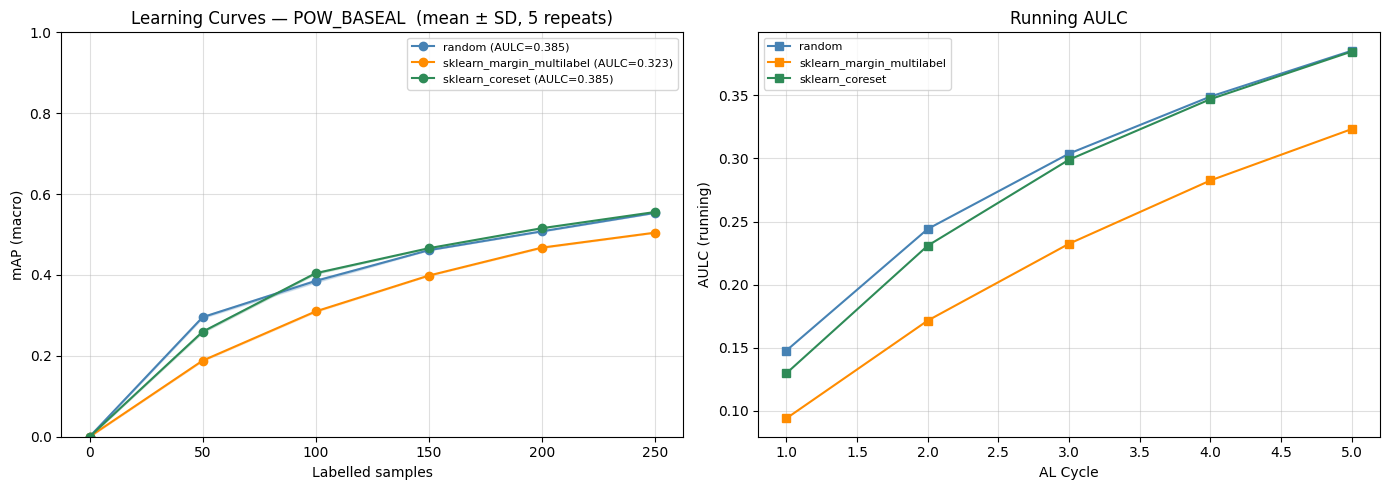


Final results — POW_BASEAL  (5 repeats per cycle)
Strategy                                   mAP      AULC
------------------------------------------------------------
random                          0.5536 ±0.0003    0.3854
sklearn_margin_multilabel       0.5046 ±0.0002    0.3233
sklearn_coreset                 0.5556 ±0.0001    0.3847


In [5]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (strategy, history), color in zip(results.items(), colors):
    n_labeled  = [0] + [h['n_labeled'] for h in history]
    mAPs       = [0.0] + [h['mAP']    for h in history]
    mAP_sds    = [0.0] + [h['mAP_sd'] for h in history]
    aulc_curve = [h['aulc_mAP'] for h in history]

    mAPs    = np.array(mAPs)
    mAP_sds = np.array(mAP_sds)
    label   = f"{strategy} (AULC={aulc_curve[-1]:.3f})"

    axes[0].plot(n_labeled, mAPs, marker='o', color=color, label=label)
    axes[0].fill_between(n_labeled, mAPs - mAP_sds, mAPs + mAP_sds, alpha=0.2, color=color)

    axes[1].plot(range(1, len(aulc_curve) + 1), aulc_curve, marker='s', color=color, label=strategy)

axes[0].set_xlabel('Labelled samples')
axes[0].set_ylabel('mAP (macro)')
axes[0].set_title(f'Learning Curves — {DATASET_NAME}  (mean ± SD, {N_REPEATS} repeats)')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].set_xlabel('AL Cycle')
axes[1].set_ylabel('AULC (running)')
axes[1].set_title('Running AULC')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nFinal results — {DATASET_NAME}  ({N_REPEATS} repeats per cycle)")
print(f"{'Strategy':<30}  {'mAP':>14}  {'AULC':>8}")
print("-" * 60)
for strategy, history in results.items():
    final = history[-1]
    print(f"{strategy:<30}  {final['mAP']:>6.4f} ±{final['mAP_sd']:>6.4f}  {final['aulc_mAP']:>8.4f}")

In [6]:
print(results)

{'random': [{'loss': 0.0033238833844661713, 'accuracy': 0.17672064777327937, 'f1_score': 0.600189647284789, 'mAP': 0.2956560061032585, 'loss_sd': 0.00011724872134562284, 'accuracy_sd': 0.0017775897263589031, 'f1_score_sd': 0.0005597877577197078, 'mAP_sd': 0.0019187347388472656, 'n_labeled': 50, 'n_unlabeled': 2914, 'repeats': 5, 'epochs': 10, 'batch_size': 32, 'sampling_time_s': 0.000538, 'annotation_cost': 141, 'calibration': {'bin_confidences': [0.05, 0.15000000000000002, 0.25, 0.3576747179031372, 0.46057766675949097, 0.566491425037384, 0.6562038064002991, 0.7529856562614441, 0.8560943603515625, 0.9496293067932129], 'bin_accuracies': [None, None, None, 0.0, 0.0, 0.4025974025974026, 0.5465587044534413, 0.5145833333333333, 0.4983221476510067, 0.4673139158576052], 'bin_counts': [0, 0, 0, 5, 14, 77, 247, 480, 596, 1545], 'ece': 0.37813133387430475, 'n_bins': 10}, 'aulc_mAP': 0.14782800305162924, 'aulc_accuracy': 0.08836032388663968, 'aulc_f1_score': 0.3000948236423945}, {'loss': 0.000433

## Step 4: Exported files

Each strategy's results are written to `results/baselines/` as a YAML file.
Inspect these to determine an appropriate `MAX_BUDGET` and confirm baseline performance.

In [7]:
print(f"Files saved to: {PROJECT_ROOT / 'results' / 'baselines'}\n")
for strategy in STRATEGIES:
    print(f"  {strategy}_{DATASET_NAME}.yaml")

Files saved to: c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\results\baselines

  random_POW_BASEAL.yaml
  sklearn_margin_multilabel_POW_BASEAL.yaml
  sklearn_coreset_POW_BASEAL.yaml


## Notes

- `MAX_BUDGET = None` — the loop runs for exactly `N_CYCLES × N_SAMPLES_PER_CYCLE` samples with no cap.
  Set `MAX_BUDGET` to a specific value once an appropriate budget has been determined from these results.
- All four strategies use the same `learning_rate`, `epochs`, and `batch_size` to ensure fair comparison.
- The YAML exports in `results/baselines/` contain the full learning curve and can be used to set
  `MAX_BUDGET` in the challenge participant notebooks.